# Knowledge graphs representing the binding paths

In [1]:
import itertools
import math
import random
from collections import Counter, defaultdict, OrderedDict
from itertools import combinations, islice
from math import nan, isnan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.linalg import expm, eig, norm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, normalize
import networkx as nx
from community import community_louvain
import community as c  # You may only need one of these
import MDAnalysis as mda
from MDAnalysis.coordinates.XTC import XTCWriter
import mdtraj as md
import pickle

/Users/adelielouet/miniforge3/envs/msm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## NEed to have run the previous graph first from p_eq
# --> filtered_merged_output
# --> p_eq_keys 
# --> unique_uplets_pre_process_0


In [3]:

### Adding pre-calcualted distances:
uplet_type=5
if uplet_type==4:
    uplet_type_label='quadruplets'
if uplet_type==3:
    uplet_type_label='triplets'
if uplet_type==5:
    uplet_type_label='quinteplets'
if uplet_type==6:
    uplet_type_label='sixuplets'
str_uplet_type=uplet_type

alpha_full_length = "alpha_syn_full_peptide"
medin_cm14 = 'medin_cm14'
medin_cm8 = 'medin_cm8'
abeta = "abeta"
medin_urea = 'medin_urea'

protein_name = medin_cm8


In [4]:

## Weighted files
file=open(f"/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/pickled_files/{protein_name}/filtered_merged_output_weighted_magnified.pckl",'rb')
filtered_merged_output = pickle.load(file)
file.close()

file=open(f"/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/pickled_files/{protein_name}/p_eq_keys_weighted_magnified.pckl",'rb')
P_eq_keys = pickle.load(file)
file.close()


file=open(f"/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/pickled_files/{protein_name}/dictionary_transitions_sorted.pckl",'rb')
dictionary_transitions_sorted = pickle.load(file)
file.close()

## Transition Matrix Knowledge Graph - Microstates

Louvain community detection applied to quintuplet states in Aβ42 (a), with node size proportional to degree centrality

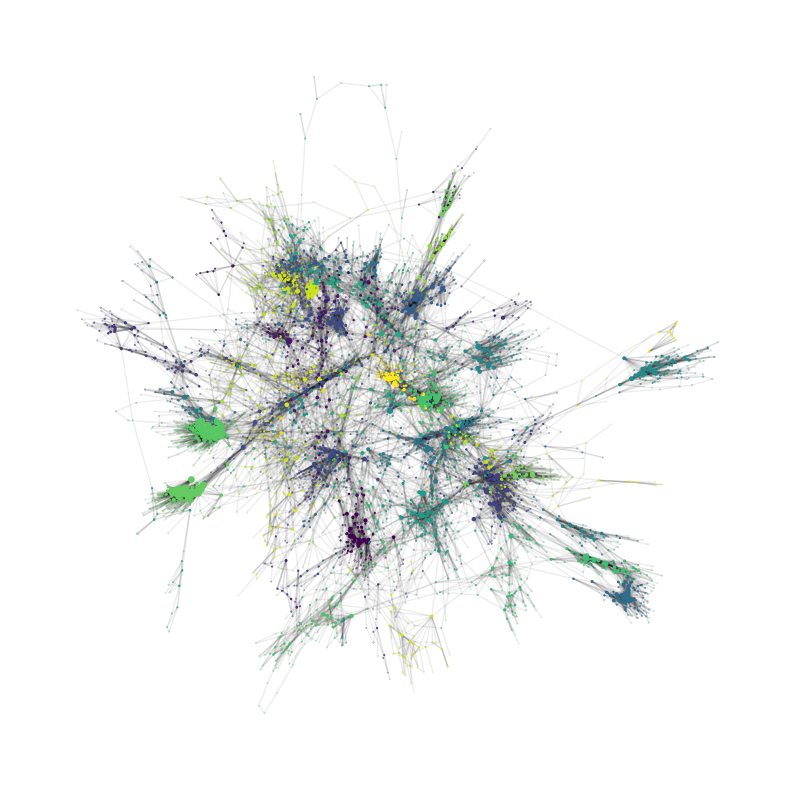

In [6]:
G=[]
G = nx.Graph()
edges=filtered_merged_output   ## This is the frequency of transitions between any two nodes - eg- [(node a, node b, transition #)] (unnormalized)

for edge, weight in edges:
    if weight<1:
        node1, node2 = edge
        G.add_edge(tuple(node1), tuple(node2), weight=1) # <-- naughty little trick to force connections between all states
    else:
        node1, node2 = edge
        G.add_edge(tuple(node1), tuple(node2), weight=weight) 
G.remove_edges_from(list(nx.selfloop_edges(G))) # <--- REemoves the self edges

communities=nx.community.louvain_communities(G, seed=random,weight=weight,resolution=3) 
#communities=nx.community.louvain_communities(G, seed=random,weight=weight,resolution=5) #for alpha-syn,remove resolution
parts = {node: i for i, community in enumerate(communities) for node in community}

#parts = c.best_partition(G)
values = [parts.get(node) for node in G.nodes()]
pos = nx.spring_layout(G)

#pos = nx.spring_layout(G, k=0.5)

betCent = nx.degree_centrality(G)
node_size =  betCent.values() #abeta

node_size =  [(v * 500)**2 for v in betCent.values()] #medin_urea ## This needs to be changed. purely visual, doesnt influence the clustering by any means
#node_size =  [(v * 20000)**2 for v in betCent.values()] #abeta
#node_size =  [(v * 10000) for v in betCent.values()] #alpha0syn

plt.figure(figsize=(10,10))

#plt.suptitle(f"Graph Network of Quinteplets {special_char}", size=18, y=0.85)
for spine in plt.gca().spines.values(): spine.set_visible(False)

nx.draw_networkx_nodes(G, pos=pos, node_color=values, node_size=node_size)
nx.draw_networkx_edges(G, pos=pos, alpha=0.07)
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/{protein_name}_graph_network.png', dpi=300)

plt.show()    


## Sigmoid Function Calculation


But first we need to decide which sigma function works for our data

63
63
63
63


/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_53857/618772441.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return A / (1 + math.exp(-k * (val - x0)))


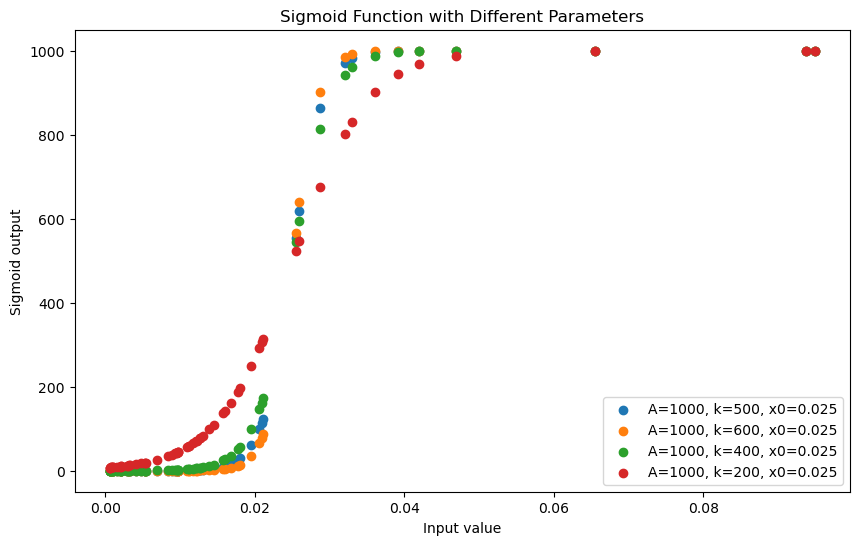

In [7]:

######### Deciding which sigma function works for data ############
inv_map = {}
for k, v in parts.items():
    inv_map[v] = inv_map.get(v, []) + [k]

inv_map_vals=[]
for keys,values in inv_map.items():
    inv_map_vals.append(values)

# filehandler_inv_map_vals = open(f"/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/pickled_files/{protein_name}/inv_map_output.pckl","wb")
# pickle.dump(inv_map,filehandler_inv_map_vals)
# filehandler_inv_map_vals.close()

values = [sum(list(P_eq_keys[node] for node in nodes)) for i, nodes in enumerate(inv_map_vals)]

def sigmoid_magnification(val, A, k, x0):
    return A / (1 + math.exp(-k * (val - x0)))

params = [
    (1000, 500, 0.025),    
    (1000, 600, 0.025),  
    (1000, 400, 0.025),    
    (1000, 200, 0.025)    # this is the best for my data 
]

# - A in amplitude (scaling factor)
# - k is steepness (rate of growth)
# - xo is midpoint (center of trans)

plt.figure(figsize=(10, 6))

for A, k, x0 in params:
    sigmoid_values = [sigmoid_magnification(val, A, k, x0) for val in values]
    print(len(sigmoid_values))
    plt.scatter(values, sigmoid_values, label=f'A={A}, k={k}, x0={x0}')

plt.title("Sigmoid Function with Different Parameters")
plt.xlabel("Input value")
plt.ylabel("Sigmoid output")
plt.legend()
plt.show()


## Louvain Community Clustering - Macrostates

Nodes within each community are aggregated into single representative states. Key high-affinity states are identified using dissociation constant (Kd) values.

/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_53857/31389682.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return A / (1 + math.exp(-k * (val - x0)))


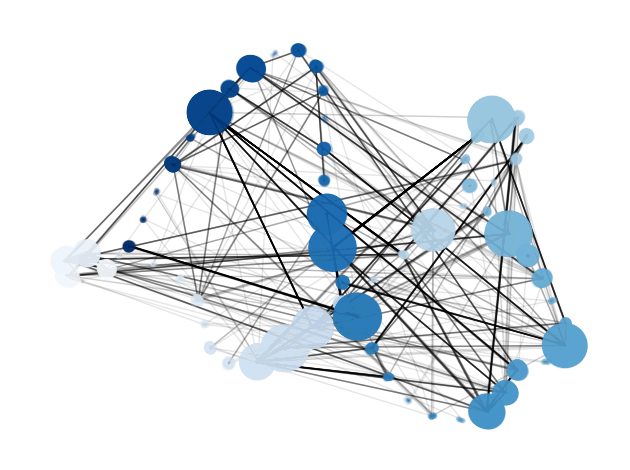

In [8]:

########################## Once sigmoid parameters decided, can move onto plot ##########################
kd_centrality = {i: sum(P_eq_keys[node] for node in community) for i, community in enumerate(communities)}
highest_kd_community = max(kd_centrality, key=kd_centrality.get)
kd_centrality_ordered={k: v for k, v in sorted(kd_centrality.items(), key=lambda item: item[1],reverse=True)}


supergraph = nx.cycle_graph(len(inv_map_vals)) # cycle graph with as many nodes as there are communities
superpos = nx.spring_layout(supergraph, scale=100,seed=2) #Computes positions for the "supergraph" 

pos = {}
for center, comm in zip(superpos.values(), inv_map_vals):
    subgraph = G.subgraph(comm) 
    subgraph_pos = nx.spring_layout(subgraph, center=center, seed=2)  
    pos.update(subgraph_pos)  
#plt.figure(figsize=(9, 7)) 
color_cycle = itertools.cycle([plt.cm.Blues(i) for i in np.linspace(0, 1, len(inv_map_vals))])
#colors = [next(color_cycle) for _ in range(len(inv_map_vals))]  
community_centrality = {i: sum(P_eq_keys[node] for node in community) for i, community in enumerate(communities)}

# We are assignign same size to each small node in the subgraph based on communal kd

def sigmoid_magnification(val, A, k, x0):
    return A / (1 + math.exp(-k * (val - x0)))

for i, (nodes, color) in enumerate(zip(inv_map_vals, color_cycle)):
    kd=list(P_eq_keys[node] for node in nodes)
    sizes_shared=[sum(kd)]*len(nodes)
    sigmoid_values = [sigmoid_magnification(val, 1000, 200, 0.025) for val in sizes_shared] #for abeta
    nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes, node_color=[color], node_size=sigmoid_values,alpha=0.07,edgecolors=color)

G.remove_edges_from(list(nx.selfloop_edges(G))) # <--- REemoves the self edges


for spine in plt.gca().spines.values(): spine.set_visible(False)

nx.draw_networkx_edges(G, pos=pos,alpha=0.1) 

#plt.title(f"Community Clustering {special_char}",fontsize=16)
plt.tight_layout()
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/{protein_name}_comm_clustering.png', dpi=300)
plt.show()

## Validating degree centrality measure

Correlation between node centrality and Kd

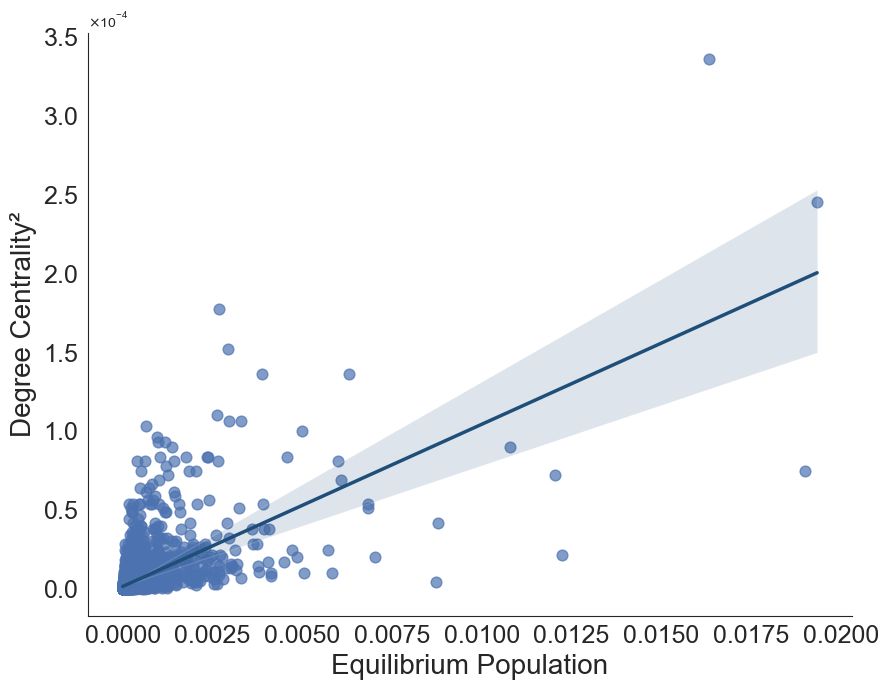

In [9]:
deg_centrality = sorted(nx.degree_centrality(G) .items(), key=lambda x: x[1], reverse=True)

metric=deg_centrality
idx= 0
metric_dict={value: key for value, key in metric}
dd = defaultdict(list)
for d in (metric_dict, P_eq_keys): 
    for key, value in d.items():
        dd[key].append(value)

values_first_ten=list(dd.values())
del values_first_ten[-1]

label='deg_centrality'
x=([item[1] for item in values_first_ten])
y=([item[0] for item in values_first_ten])
y_sq=np.square(y)

sns.set_style("white")  # No grid background
plt.figure(figsize=(9, 7)) #rather than 6
#plt.title('Degree Centrality vs. Equilibrium Population', fontsize=18)
from matplotlib.ticker import ScalarFormatter

sns.regplot(
    x=x,
    y=y_sq,
    scatter_kws={'alpha': 0.7, 'color': '#4C72B0', 's': 60},
    line_kws={'color': '#1f4e79', 'linewidth': 2.5}
)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.xlabel('Equilibrium Population', fontsize=20)
plt.ylabel('Degree Centrality²', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

sns.despine()  # Remove top/right axes

plt.tight_layout() # to fit everything in the prescribed area
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/{protein_name}_deg_centrality.png', dpi=300)
plt.show()



The following stored options are needing to run the additional_analysis.ipynb script

In [12]:
%store kd_centrality_ordered
%store inv_map
%store dictionary_transitions_sorted

Stored 'kd_centrality_ordered' (dict)
Stored 'inv_map' (dict)
Stored 'dictionary_transitions_sorted' (dict)
